## NLP Mini Project — Sentiment Analysis

Course: Artificial Intelligent
Dataset: `electronic_product_reviews_cleaned_part1.csv` — Daraz.lk electronic product reviews (Sinhala, code-mixed Sinhala-in-English, and English)

The NLP pipeline:
`Data Collection → Cleaning → Tokenization → Feature Extraction → Model Training → Evaluation`


## 0. Setup

In [1]:
# Core libraries (baseline pipeline only needs these)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42
DATA_PATH = "electronic_product_reviews_cleaned_part1.csv"  # <-- update path if needed


## 1. Data Collection & Exploration
*(Pipeline step 1: "Data Collection")*

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df = df.dropna(subset=['review']).reset_index(drop=True)  # drop the 1 empty review
df.head(3)


Shape: (5960, 9)


,sentence_id,product_name,price,rating,review,cleaned_review,aspect_sentiment_annotation,review_type,category
0,1,Smart Watch T900 Ultra 49mm Big 2.09 inch 2023...,"Rs. 3,000",5,මේක මරු හැබැයි එබව්ට් එකේ තියෙන්නේ t900 ultra ...,මේක මරු හැබැයි එබව්ට් එකේ තියෙන්නේ t900 ultra ...,NaN,Pure_Sinhala,electronic
1,2,Smart Watch T900 Ultra 49mm Big 2.09 inch 2023...,"Rs. 3,000",5,super nice ඇතටම නියමයි කියන්න වචන නැ,super nice ඇතටම නියමයි කියන්න වචන නැ,NaN,Pure_Sinhala,electronic
2,3,Smart Watch T900 Ultra 49mm Big 2.09 inch 2023...,"Rs. 3,000",5,🔥 මේක අනිවාර්යෙන්ම ගන්න. දවස් තුනෙන් ආවා. කියන...,🔥 මේක අනිවාර්යෙන්ම ගන්න. දවස් තුනෙන් ආවා. කියන...,NaN,Pure_Sinhala,electronic


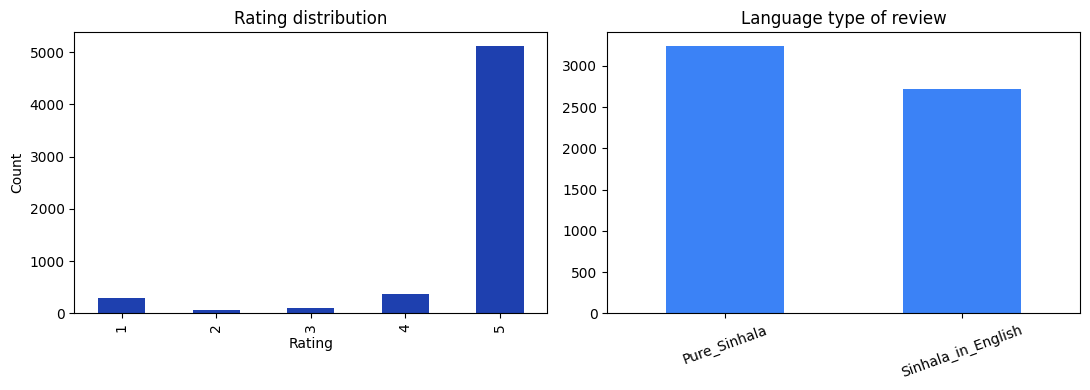

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#1e40af')
axes[0].set_title('Rating distribution'); axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

df['review_type'].value_counts().plot(kind='bar', ax=axes[1], color='#3b82f6')
axes[1].set_title('Language type of review'); axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig('eda_overview.png', dpi=150); plt.show()


## 2. Sentiment Labeling

Map star ratings to 3 sentiment classes (Positive / Neutral / Negative output classes):

| Rating | Sentiment |
|---|---|
| 4–5 | Positive |
| 3 | Neutral |
| 1–2 | Negative |


sentiment
positive    5487
negative     362
neutral      110
Name: count, dtype: int64
sentiment
positive    92.1%
negative     6.1%
neutral      1.8%
Name: proportion, dtype: object


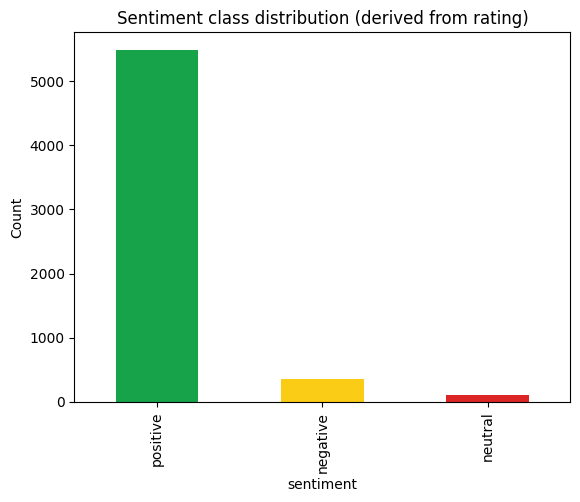

In [4]:
def rating_to_label(r):
    if r >= 4:
        return 'positive'
    elif r == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['rating'].apply(rating_to_label)
print(df['sentiment'].value_counts())
print((df['sentiment'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

df['sentiment'].value_counts().plot(kind='bar', color=['#16a34a','#facc15','#dc2626'])
plt.title('Sentiment class distribution (derived from rating)'); plt.ylabel('Count'); plt.show()


## 3. Text Preprocessing
*(Pipeline step 2: "Cleaning")*

In [5]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)                       # URLs
    text = re.sub(r'[\U0001F300-\U0001FAFF\U00002700-\U000027BF\u2600-\u26FF]', ' ', text)  # emoji
    text = re.sub(r'([!?.,])\1{1,}', r'\1', text)                        # squeeze punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['review'].apply(clean_text)
df[['review', 'clean_text']].sample(5, random_state=1)


,review,clean_text
2209,fast dilivery dawas deken awa oder eka kiyann ...,fast dilivery dawas deken awa oder eka kiyann ...
687,"Watch එකනම් සුපිරියක්, ගෙවන ගානට හොදටම වටිනව. ...","Watch එකනම් සුපිරියක්, ගෙවන ගානට හොදටම වටිනව. ..."
4734,I phone 12 pro ek 3 park charge kara puluwn s ...,I phone 12 pro ek 3 park charge kara puluwn s ...
2804,fhrk meka hodai,fhrk meka hodai
3529,"meka wada krna widiya kiyla denko, ebuwata kis...","meka wada krna widiya kiyla denko, ebuwata kis..."


## 4. Tokenization
*(Pipeline step 3: "Tokenization")*

For the **baseline models** we use `TfidfVectorizer`'s built-in word tokenizer (word-level, with
1-2 word n-grams to capture short phrases like "kalu wala" / "not good").

For the **Transformer model** (Section 7) we use the model's own **sub-word tokenizer**
(WordPiece for BERT), which is what the slide's "Sub-word Tokenization" box refers to — it handles
unseen/rare Sinhala-romanized words far better than whole-word tokenization.


In [6]:
sample = df['clean_text'].iloc[0]
print("Example text:", sample)
print("Simple whitespace tokens:", sample.split()[:15])


Example text: මේක මරු හැබැයි එබව්ට් එකේ තියෙන්නේ t900 ultra 2 kiyala හැබැයි හොදයි බැට්රිය දවස් 2 තියෙ thaks daraz ️ ️
Simple whitespace tokens: ['මේක', 'මරු', 'හැබැයි', 'එබව්ට්', 'එකේ', 'තියෙන්නේ', 't900', 'ultra', '2', 'kiyala', 'හැබැයි', 'හොදයි', 'බැට්රිය', 'දවස්', '2']


## 5. Train / Validation / Test Split

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.20,
    random_state=RANDOM_STATE, stratify=df['sentiment'])

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_STATE, stratify=y_temp)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")


Train: 4767  Val: 596  Test: 596


## 6. Text Representation + Traditional Baseline Models
*(Pipeline step 4 "Feature Extraction" + "Traditional Baseline Models")*

TF-IDF (word 1-2 grams) → Naive Bayes, Logistic Regression, Linear SVM, Random Forest.


In [8]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

models = {
    "Naive Bayes":         MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Linear SVM":          LinearSVC(class_weight='balanced'),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                    random_state=RANDOM_STATE),
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    p, r, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    baseline_results[name] = {"model": model, "accuracy": acc, "precision": p, "recall": r, "f1": f1}
    print(f"{name:22s} acc={acc:.3f}  macro-P={p:.3f}  macro-R={r:.3f}  macro-F1={f1:.3f}")


Naive Bayes            acc=0.921  macro-P=0.307  macro-R=0.333  macro-F1=0.320
Logistic Regression    acc=0.869  macro-P=0.467  macro-R=0.552  macro-F1=0.494
Linear SVM             acc=0.911  macro-P=0.525  macro-R=0.515  macro-F1=0.520
Random Forest          acc=0.923  macro-P=0.686  macro-R=0.424  macro-F1=0.463


Best baseline model: Linear SVM

              precision    recall  f1-score   support

    negative       0.51      0.50      0.51        36
     neutral       0.11      0.09      0.10        11
    positive       0.95      0.95      0.95       549

    accuracy                           0.91       596
   macro avg       0.52      0.52      0.52       596
weighted avg       0.91      0.91      0.91       596



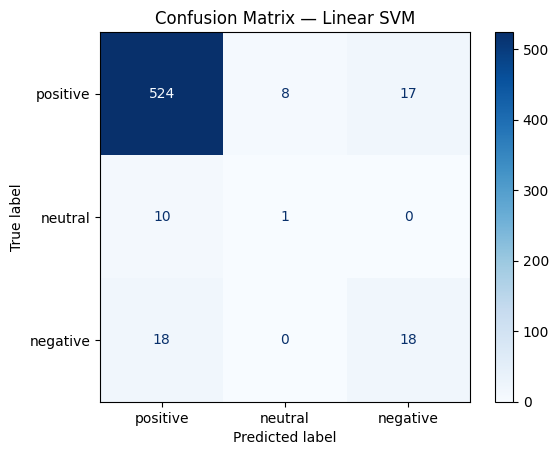

In [ ]:
best_name = max(baseline_results, key=lambda k: baseline_results[k]['f1'])
best_model = baseline_results[best_name]['model']
print(f"Best baseline model: {best_name}\n")
print(classification_report(y_test, best_model.predict(X_test_tfidf), zero_division=0))

cm = confusion_matrix(y_test, best_model.predict(X_test_tfidf), labels=['positive','neutral','negative'])
ConfusionMatrixDisplay(cm, display_labels=['positive','neutral','negative']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}'); plt.show()


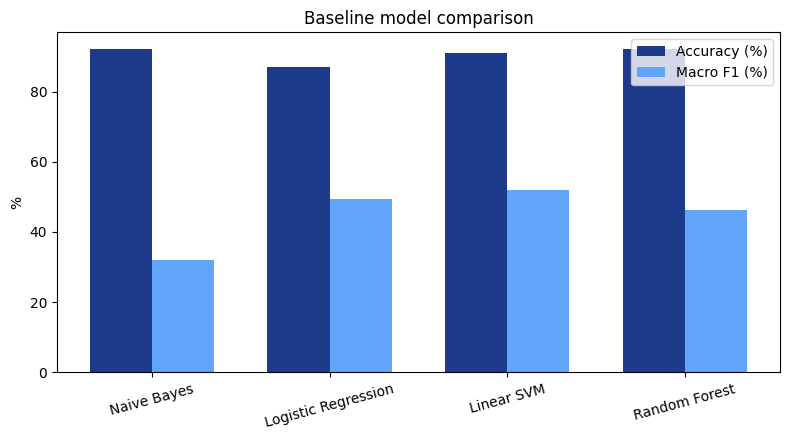

In [ ]:
names = list(baseline_results.keys())
accs = [baseline_results[n]['accuracy']*100 for n in names]
f1s  = [baseline_results[n]['f1']*100 for n in names]

x = np.arange(len(names)); width = 0.35
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(x - width/2, accs, width, label='Accuracy (%)', color='#1e3a8a')
ax.bar(x + width/2, f1s,  width, label='Macro F1 (%)', color='#60a5fa')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('%'); ax.set_title('Baseline model comparison'); ax.legend()
plt.tight_layout(); plt.savefig('baseline_results.png', dpi=150); plt.show()


## 7. Transformer-Based Model — Fine-Tuned Multilingual BERT
*(Pipeline step 5 "Model Training" + "Transformer-Based Model")*

In [11]:
# --- Run this cell in Colab / a machine with internet + GPU ---
# !pip install -q transformers torch scikit-learn accelerate

import torch
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)

MODEL_NAME = "bert-base-multilingual-cased"   # multilingual -> handles Sinhala + English + romanized text
LABELS = ['negative', 'neutral', 'positive']
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = [label2id[l] for l in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], truncation=True, padding='max_length',
                              max_length=self.max_len, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_ds = ReviewDataset(X_train, y_train, tokenizer)
val_ds   = ReviewDataset(X_val,   y_val,   tokenizer)
test_ds  = ReviewDataset(X_test,  y_test,  tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS), id2label=id2label, label2id=label2id)


c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7591.81it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                

In [12]:
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

training_args = TrainingArguments(
    output_dir="./bert_sentiment",
    learning_rate=2e-5,          # from the "Hyperparameters" slide
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,          # slide range: 3-5
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    weight_decay=0.01,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()


c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.300045,0.318453,0.921141,0.307047,0.333333,0.319651
2,0.268467,0.290315,0.906040,0.404803,0.379781,0.386901
3,0.221962,0.367743,0.907718,0.391954,0.363084,0.368377
4,0.237713,0.352506,0.902685,0.409252,0.395871,0.400697


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.73it/s]
c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]
c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.50it/s]
c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|████

TrainOutput(global_step=1192, training_loss=0.26372701369676016, metrics={'train_runtime': 5236.9328, 'train_samples_per_second': 3.641, 'train_steps_per_second': 0.228, 'total_flos': 1254261662309376.0, 'train_loss': 0.26372701369676016, 'epoch': 4.0})

c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.237713,0.284719,4,0.912752,0.436286,0.416818,0.424246


{'eval_loss': 0.28471866250038147, 'eval_accuracy': 0.912751677852349, 'eval_precision': 0.43628631560676084, 'eval_recall': 0.4168184578020644, 'eval_f1': 0.42424586610633125}


c:\Users\Snyh\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.37      0.28      0.32        36
     neutral       0.00      0.00      0.00        11
    positive       0.94      0.97      0.96       549

    accuracy                           0.91       596
   macro avg       0.44      0.42      0.42       596
weighted avg       0.89      0.91      0.90       596



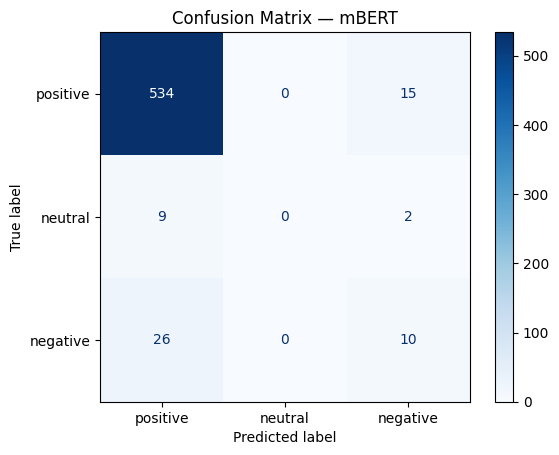

In [13]:
# Final evaluation on the held-out test set
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)

preds = trainer.predict(test_ds)
y_pred = [id2label[i] for i in np.argmax(preds.predictions, axis=1)]
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=['positive','neutral','negative'])
ConfusionMatrixDisplay(cm, display_labels=['positive','neutral','negative']).plot(cmap='Blues')
plt.title('Confusion Matrix — mBERT'); plt.show()


## 8. Baseline vs. Transformer — Final Comparison

In [14]:
final_results = pd.DataFrame([
    {"Model": name, "Accuracy": r['accuracy'], "Macro F1": r['f1']}
    for name, r in baseline_results.items()
] + [
    {"Model": "mBERT (fine-tuned)", "Accuracy": None, "Macro F1": None}  # <- fill in from Section 7
])
final_results


,Model,Accuracy,Macro F1
0,Naive Bayes,0.921141,0.319651
1,Logistic Regression,0.869128,0.493823
2,Linear SVM,0.911074,0.519635
3,Random Forest,0.922819,0.463379
4,mBERT (fine-tuned),NaN,NaN


## 9. Error Analysis

In [15]:
wrong = X_test[best_model.predict(X_test_tfidf) != y_test.values]
wrong_true = y_test[best_model.predict(X_test_tfidf) != y_test.values]
wrong_pred = pd.Series(best_model.predict(X_test_tfidf), index=y_test.index)[y_test != pd.Series(best_model.predict(X_test_tfidf), index=y_test.index)]

pd.DataFrame({
    'text': wrong.values[:10],
    'true_label': wrong_true.values[:10],
}).head(10)


,text,true_label
0,kisima wadak na aran dawasai bluetooth pair we...,negative
1,item eka nam godak hodai.sound nam hodai.ikman...,neutral
2,බැටරිය නම් ඉක්මනින් බහිනවා.මම දෙකක් ගත්තා.,negative
3,මෙලෝ වැඩක් නෑ.පට්ට පරන බඩු.වැඩත් නෑ,negative
4,good sounds,positive
5,සද්දෙ සුපිරි,positive
6,ලොකු කොපියක් කිසිම කොලිටියක් නැ,negative
7,illuwe 1346 ewala thiyenne 1345,negative
8,හිතුවට වඩා පොඩි ඒත් සද්දෙ නම් තියෙනවා. පැකිං න...,positive
9,බෙන්ස් අඩුයි සබ්දය නම් හොඳින් තියෙනවා,positive
